# Backward Chaining – Sistem Rekomendasi Tempat Magang

**Proyek PBL: Sistem Rekomendasi Penempatan Magang**  
Program Studi D4 Teknik Informatika – Politeknik Negeri Malang  

---

## Deskripsi Metode

**Backward Chaining** (penalaran mundur) adalah strategi inferensi yang dimulai dari **hipotesis (goal)** yang ingin dibuktikan, kemudian menelusuri apakah fakta-fakta yang tersedia dapat mendukung hipotesis tersebut. Berbeda dengan Forward Chaining yang berangkat dari fakta, Backward Chaining berangkat dari tujuan (goal-driven).

Dalam konteks sistem rekomendasi magang ini, hipotesis yang diuji adalah:  
> *"Apakah mahasiswa X cocok untuk posisi magang di perusahaan Y?"*

Sistem akan menelusuri mundur dari hipotesis tersebut untuk membuktikannya melalui pengecekan fakta-fakta:
1. Apakah IPK mahasiswa memenuhi syarat minimum perusahaan?
2. Apakah skill mahasiswa mencakup skill yang dibutuhkan?
3. Apakah teknologi yang dikuasai mahasiswa sesuai dengan teknologi yang digunakan perusahaan?
4. Apakah minat bidang mahasiswa relevan dengan posisi yang ditawarkan?

---

## Cell 1 – Import Library

In [ ]:
import pandas as pd
import numpy as np
from typing import List, Dict, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport")

Library berhasil diimport


## Cell 2 – Load Dataset Preprocessed

In [ ]:
# Load dataset hasil preprocessing
FILE_PATH = 'PBL_DATA_preprocessed.xlsx'

df_mahasiswa = pd.read_excel(FILE_PATH, sheet_name='MAHASISWA')
df_perusahaan = pd.read_excel(FILE_PATH, sheet_name='PERUSAHAAN')

print(f"Dataset MAHASISWA: {df_mahasiswa.shape[0]} baris, {df_mahasiswa.shape[1]} kolom")
print(f"Dataset PERUSAHAAN: {df_perusahaan.shape[0]} baris, {df_perusahaan.shape[1]} kolom")
print("\n=== Preview MAHASISWA ===")
display(df_mahasiswa.head(3))
print("\n=== Preview PERUSAHAAN ===")
display(df_perusahaan.head(3))

Dataset MAHASISWA: 305 baris, 7 kolom
Dataset PERUSAHAAN: 30 baris, 11 kolom

=== Preview MAHASISWA ===


,NIM,Nama,Prodi,Teknologi,Minat_Bidang,Skill,IPK
0,848822,Dinda SIta,D4 Teknik Informatika,"HTML, CSS, JavaScript, TailwindCSS, Bootstrap,...","Software Developer, Artificial Intelligence, D...","Python, JavaScript, TypeScript, Java, SQL, Tai...",3.61
1,242443,Hadi Putri,D4 Teknik Informatika,"Laravel, NestJs, Wordpress, IoT",Software Developer,"JavaScript, Laravel, NestJS",3.87
2,665049,Rizky Anggraini,D4 Teknik Informatika,"Python, JavaScript, TypeScript, PHP, SQL, Djan...","Software Developer, Artificial Intelligence, D...","Python, JavaScript, TypeScript, PHP, Java, SQL...",3.90



=== Preview PERUSAHAAN ===


,ID_Perusahaan,Nama_Perusahaan,Profil_Perusahaan,Bidang_Industri,Posisi_Magang,Minimal_IPK,Job_Description,Skill_Dibutuhkan,Teknologi_Digunakan,Durasi_Bulan,Status_Paid
0,P001,PT Indoprima Gemilang,PT Indoprima Gemilang berdiri sejak 1976 di Su...,swasta nasional,IT/System Development Intern,3,Membantu pengembangan dan pemeliharaan sistem ...,"Pemrograman dasar, logika sistem, komunikasi, ...","Visual Basic / VB.NET, MySQL, atau teknologi w...",6,Paid
1,P002,Pengembangan SIPP – PT Link Apisindo Media & D...,PT Link Apisindo Media adalah perusahaan IT di...,swasta nasional,Backend Engineer / Frontend Engineer / AI Engi...,3,"Backend: pengembangan API, integrasi data, pen...","Backend: REST API, database management, system...","Backend: Laravel/FastAPI, MySQL/PostgreSQL, Do...",5,Paid
2,P003,Pengembangan Platform Satu Peta Jatim – PT Lin...,PT Link Apisindo Media berkolaborasi dengan Di...,swasta nasional,Data Engineer / Backend Developer / Frontend D...,3,"Data: ETL data spasial/non-spasial, integrasi ...","Data: ETL, GIS, database. Backend: Python, RES...","PostGIS, Python (FastAPI), JavaScript, OpenLay...",5,Paid


## Cell 3 – Fungsi Pembantu: Parsing Multi-Nilai

In [ ]:
def parse_multi_value(value: str) -> List[str]:
    """
    Memparse kolom multi-nilai yang dipisahkan koma menjadi list.
    Melakukan normalisasi lowercase dan strip whitespace.
    """
    if pd.isna(value) or str(value).strip() == '':
        return []
    items = [item.strip().lower() for item in str(value).split(',')]
    return [item for item in items if item]


def normalize_text(text: str) -> str:
    """Normalisasi teks: lowercase dan strip."""
    return str(text).strip().lower()


def compute_overlap_score(list_a: List[str], list_b: List[str]) -> float:
    """
    Menghitung skor overlap antara dua list.
    Skor = jumlah elemen yang sama / jumlah elemen list_b (requirement).
    Menggunakan partial matching (substring).
    """
    if not list_b:
        return 1.0  # tidak ada requirement maka otomatis terpenuhi
    if not list_a:
        return 0.0

    matched = 0
    for req in list_b:
        # Cek exact match atau partial match (substring)
        for item in list_a:
            if req in item or item in req:
                matched += 1
                break

    return matched / len(list_b)


print("Fungsi pembantu berhasil didefinisikan")

# Contoh penggunaan
contoh_skill_mhs = parse_multi_value("Python, JavaScript, React.js, MySQL, Git")
contoh_skill_req = parse_multi_value("Python, REST API, database")
print(f"Contoh skill mahasiswa: {contoh_skill_mhs}")
print(f"Contoh skill requirement: {contoh_skill_req}")
print(f"Overlap score: {compute_overlap_score(contoh_skill_mhs, contoh_skill_req):.2f}")

Fungsi pembantu berhasil didefinisikan
Contoh skill mahasiswa: ['python', 'javascript', 'react.js', 'mysql', 'git']
Contoh skill requirement: ['python', 'rest api', 'database']
Overlap score: 0.33


## Cell 4 – Definisi Knowledge Base (Basis Pengetahuan)

In [ ]:
class KnowledgeBase:
    """
    Basis pengetahuan untuk sistem rekomendasi magang.
    Menyimpan fakta dan aturan yang digunakan dalam proses inferensi.
    """

    def __init__(self, df_mahasiswa: pd.DataFrame, df_perusahaan: pd.DataFrame):
        self.mahasiswa = self._build_mahasiswa_facts(df_mahasiswa)
        self.perusahaan = self._build_perusahaan_facts(df_perusahaan)

        # Threshold untuk penerimaan sub-goal
        self.THRESHOLD_SKILL = 0.3       # minimal 30% skill match
        self.THRESHOLD_TEKNOLOGI = 0.25  # minimal 25% teknologi match
        self.THRESHOLD_MINAT = 0.2       # minimal 20% minat relevan

        print(f"KnowledgeBase dibangun: {len(self.mahasiswa)} mahasiswa, {len(self.perusahaan)} perusahaan")

    def _build_mahasiswa_facts(self, df: pd.DataFrame) -> Dict:
        """Membangun fakta mahasiswa dari dataframe."""
        facts = {}
        for _, row in df.iterrows():
            nim = str(row['NIM'])
            facts[nim] = {
                'NIM': nim,
                'Nama': str(row['Nama']),
                'Prodi': str(row['Prodi']),
                'IPK': float(row['IPK']),
                'Skill': parse_multi_value(row['Skill']),
                'Teknologi': parse_multi_value(row['Teknologi']),
                'Minat_Bidang': parse_multi_value(row['Minat_Bidang'])
            }
        return facts

    def _build_perusahaan_facts(self, df: pd.DataFrame) -> Dict:
        """Membangun fakta perusahaan dari dataframe."""
        facts = {}
        for _, row in df.iterrows():
            pid = str(row['ID_Perusahaan'])
            facts[pid] = {
                'ID': pid,
                'Nama': str(row['Nama_Perusahaan']),
                'Posisi': str(row['Posisi_Magang']),
                'Minimal_IPK': float(row['Minimal_IPK']),
                'Skill_Dibutuhkan': parse_multi_value(row['Skill_Dibutuhkan']),
                'Teknologi_Digunakan': parse_multi_value(row['Teknologi_Digunakan']),
                'Durasi': int(row['Durasi_Bulan']),
                'Status_Paid': str(row['Status_Paid'])
            }
        return facts

    def get_mahasiswa(self, nim: str) -> Optional[Dict]:
        return self.mahasiswa.get(nim)

    def get_perusahaan(self, pid: str) -> Optional[Dict]:
        return self.perusahaan.get(pid)


# Inisialisasi KnowledgeBase
kb = KnowledgeBase(df_mahasiswa, df_perusahaan)

KnowledgeBase dibangun: 305 mahasiswa, 30 perusahaan


## Cell 5 – Definisi Sub-Goals dan Aturan Backward Chaining

In [ ]:
class BackwardChainingEngine:
    """
    Mesin inferensi Backward Chaining untuk rekomendasi magang.

    Hierarki goal:
    GOAL: mahasiswa_cocok(mahasiswa_X, perusahaan_Y)
      └── Sub-goal 1: ipk_memenuhi(mahasiswa_X, perusahaan_Y)
      └── Sub-goal 2: skill_match(mahasiswa_X, perusahaan_Y)
      └── Sub-goal 3: teknologi_match(mahasiswa_X, perusahaan_Y)
      └── Sub-goal 4: minat_relevan(mahasiswa_X, perusahaan_Y)
    """

    def __init__(self, kb: KnowledgeBase):
        self.kb = kb
        self.trace_log = []  # menyimpan jejak inferensi

    def _log(self, message: str, level: int = 0):
        """Mencatat jejak proses inferensi."""
        indent = '  ' * level
        self.trace_log.append(f"{indent}{message}")

    # ─────────────────────────────────────────────
    # SUB-GOAL 1: IPK memenuhi syarat minimum
    # ─────────────────────────────────────────────
    def prove_ipk_memenuhi(self, mhs: Dict, prs: Dict) -> Tuple[bool, float, str]:
        """
        Membuktikan sub-goal: IPK mahasiswa >= Minimal IPK perusahaan.
        Returns: (terbukti, skor, penjelasan)
        """
        self._log(f"[Sub-Goal 1] Membuktikan: ipk_memenuhi({mhs['Nama']}, {prs['Nama']})", 1)

        ipk_mhs = mhs['IPK']
        ipk_min = prs['Minimal_IPK']

        if ipk_min == 0:
            skor = 1.0
            terbukti = True
            penjelasan = f"Tidak ada syarat IPK minimum → Sub-goal terbukti (skor=1.0)"
        elif ipk_mhs >= ipk_min:
            # Skor proporsional: semakin tinggi IPK, semakin tinggi skor
            skor = min(1.0, ipk_mhs / 4.0)
            terbukti = True
            penjelasan = f"IPK {ipk_mhs:.2f} >= {ipk_min:.2f} → Sub-goal terbukti (skor={skor:.2f})"
        else:
            skor = 0.0
            terbukti = False
            penjelasan = f"IPK {ipk_mhs:.2f} < {ipk_min:.2f} → Sub-goal GAGAL"

        self._log(penjelasan, 2)
        return terbukti, skor, penjelasan

    # ─────────────────────────────────────────────
    # SUB-GOAL 2: Skill match
    # ─────────────────────────────────────────────
    def prove_skill_match(self, mhs: Dict, prs: Dict) -> Tuple[bool, float, str]:
        """
        Membuktikan sub-goal: skill mahasiswa memenuhi skill yang dibutuhkan.
        Returns: (terbukti, skor, penjelasan)
        """
        self._log(f"[Sub-Goal 2] Membuktikan: skill_match({mhs['Nama']}, {prs['Nama']})", 1)

        skill_mhs = mhs['Skill']
        skill_req = prs['Skill_Dibutuhkan']

        skor = compute_overlap_score(skill_mhs, skill_req)
        terbukti = skor >= self.kb.THRESHOLD_SKILL

        # Identifikasi skill yang cocok
        matched = []
        for req in skill_req:
            for item in skill_mhs:
                if req in item or item in req:
                    matched.append(req)
                    break

        penjelasan = (f"Skill match: {len(matched)}/{len(skill_req)} "
                     f"(skor={skor:.2f}, threshold={self.kb.THRESHOLD_SKILL}) "
                     f"→ {'Terbukti' if terbukti else 'GAGAL'}")
        if matched:
            penjelasan += f" | Cocok: {', '.join(matched[:5])}"

        self._log(penjelasan, 2)
        return terbukti, skor, penjelasan

    # ─────────────────────────────────────────────
    # SUB-GOAL 3: Teknologi match
    # ─────────────────────────────────────────────
    def prove_teknologi_match(self, mhs: Dict, prs: Dict) -> Tuple[bool, float, str]:
        """
        Membuktikan sub-goal: teknologi mahasiswa sesuai teknologi perusahaan.
        Returns: (terbukti, skor, penjelasan)
        """
        self._log(f"[Sub-Goal 3] Membuktikan: teknologi_match({mhs['Nama']}, {prs['Nama']})", 1)

        tek_mhs = mhs['Teknologi']
        tek_req = prs['Teknologi_Digunakan']

        skor = compute_overlap_score(tek_mhs, tek_req)
        terbukti = skor >= self.kb.THRESHOLD_TEKNOLOGI

        penjelasan = (f"Teknologi match: skor={skor:.2f}, threshold={self.kb.THRESHOLD_TEKNOLOGI} "
                     f"→ {'Terbukti' if terbukti else 'GAGAL'}")

        self._log(penjelasan, 2)
        return terbukti, skor, penjelasan

    # ─────────────────────────────────────────────
    # SUB-GOAL 4: Minat relevan
    # ─────────────────────────────────────────────
    def prove_minat_relevan(self, mhs: Dict, prs: Dict) -> Tuple[bool, float, str]:
        """
        Membuktikan sub-goal: minat mahasiswa relevan dengan posisi magang.
        Dilakukan dengan keyword matching antara minat bidang dan nama/deskripsi posisi.
        Returns: (terbukti, skor, penjelasan)
        """
        self._log(f"[Sub-Goal 4] Membuktikan: minat_relevan({mhs['Nama']}, {prs['Nama']})", 1)

        minat_mhs = mhs['Minat_Bidang']
        posisi_lower = normalize_text(prs['Posisi'])

        # Peta kata kunci minat ke kata kunci posisi
        MINAT_KEYWORD_MAP = {
            'software developer': ['developer', 'programmer', 'engineer', 'fullstack', 'backend', 'frontend', 'web'],
            'artificial intelligence': ['ai', 'machine learning', 'data science', 'nlp', 'deep learning', 'ml'],
            'data technology': ['data', 'analyst', 'engineer', 'etl', 'database', 'bi', 'analytics'],
            'multimedia and game': ['game', 'multimedia', 'ui/ux', 'creative', 'design'],
            'information system': ['system', 'analyst', 'erp', 'governance', 'compliance', 'qa'],
            'business analyst': ['analyst', 'business', 'product', 'management'],
            'cybersecurity': ['security', 'cyber', 'soc', 'compliance', 'network'],
            'networking': ['network', 'infrastructure', 'infra', 'devops', 'cloud'],
            'iot': ['iot', 'embedded', 'hardware', 'sensor', 'digital twin'],
            'blockchain': ['blockchain', 'smart contract', 'web3', 'distributed']
        }

        max_relevance = 0.0
        best_minat = ''

        for minat in minat_mhs:
            # Cari keyword yang relevan
            keywords = []
            for key, kw_list in MINAT_KEYWORD_MAP.items():
                if key in minat or minat in key:
                    keywords = kw_list
                    break

            if not keywords:
                # Gunakan minat langsung sebagai keyword
                keywords = minat.split()

            # Hitung relevansi berdasarkan keyword dalam posisi
            matched_kw = sum(1 for kw in keywords if kw in posisi_lower)
            relevance = matched_kw / len(keywords) if keywords else 0

            if relevance > max_relevance:
                max_relevance = relevance
                best_minat = minat

        # Berikan bonus jika ada keyword minat langsung dalam nama posisi
        for minat in minat_mhs:
            for word in minat.split():
                if len(word) > 3 and word in posisi_lower:
                    max_relevance = max(max_relevance, 0.5)

        terbukti = max_relevance >= self.kb.THRESHOLD_MINAT
        penjelasan = (f"Minat terbaik: '{best_minat}' → relevansi={max_relevance:.2f}, "
                     f"threshold={self.kb.THRESHOLD_MINAT} → {'Terbukti' if terbukti else 'GAGAL'}")

        self._log(penjelasan, 2)
        return terbukti, max_relevance, penjelasan

    # ─────────────────────────────────────────────
    # MAIN GOAL: Mahasiswa cocok dengan perusahaan
    # ─────────────────────────────────────────────
    def prove_goal(
        self,
        nim: str,
        pid: str,
        verbose: bool = False
    ) -> Dict:
        """
        Membuktikan main goal: mahasiswa_cocok(nim, pid).

        Proses Backward Chaining:
        1. Tetapkan goal: mahasiswa cocok dengan perusahaan
        2. Identifikasi sub-goals yang harus dibuktikan
        3. Buktikan setiap sub-goal satu per satu
        4. Jika semua sub-goal terbukti → main goal terbukti

        Returns: dict berisi hasil dan detail inferensi
        """
        self.trace_log = []

        mhs = self.kb.get_mahasiswa(nim)
        prs = self.kb.get_perusahaan(pid)

        if not mhs:
            return {'error': f'Mahasiswa NIM {nim} tidak ditemukan'}
        if not prs:
            return {'error': f'Perusahaan ID {pid} tidak ditemukan'}

        self._log(f"="*60)
        self._log(f"[GOAL] Membuktikan: mahasiswa_cocok({mhs['Nama']}, {prs['Nama']})")
        self._log(f"[INFO] Posisi: {prs['Posisi']}")
        self._log(f"="*60)
        self._log(f"Dekomposisi goal menjadi 4 sub-goals:")

        # Buktikan setiap sub-goal
        sg1_ok, skor_ipk, pen_ipk = self.prove_ipk_memenuhi(mhs, prs)
        sg2_ok, skor_skill, pen_skill = self.prove_skill_match(mhs, prs)
        sg3_ok, skor_tek, pen_tek = self.prove_teknologi_match(mhs, prs)
        sg4_ok, skor_minat, pen_minat = self.prove_minat_relevan(mhs, prs)

        # ──────────────────────────────────────────
        # Logika pembuktian main goal:
        # IPK WAJIB terpenuhi (hard constraint)
        # Minimal 2 dari 3 sub-goal lainnya harus terbukti
        # ──────────────────────────────────────────
        sub_goals_optional = [sg2_ok, sg3_ok, sg4_ok]
        jumlah_terbukti = sum(sub_goals_optional)

        goal_terbukti = sg1_ok and (jumlah_terbukti >= 2)

        # Hitung skor akhir (weighted average)
        # IPK: bobot 25%, Skill: 35%, Teknologi: 25%, Minat: 15%
        BOBOT = {'ipk': 0.25, 'skill': 0.35, 'teknologi': 0.25, 'minat': 0.15}
        skor_akhir = (
            BOBOT['ipk'] * skor_ipk +
            BOBOT['skill'] * skor_skill +
            BOBOT['teknologi'] * skor_tek +
            BOBOT['minat'] * skor_minat
        )

        self._log(f"\n[KESIMPULAN]")
        self._log(f"  Sub-goal IPK    : {'TERBUKTI' if sg1_ok else 'GAGAL'} (skor={skor_ipk:.2f})")
        self._log(f"  Sub-goal Skill  : {'TERBUKTI' if sg2_ok else 'GAGAL'} (skor={skor_skill:.2f})")
        self._log(f"  Sub-goal Tek    : {'TERBUKTI' if sg3_ok else 'GAGAL'} (skor={skor_tek:.2f})")
        self._log(f"  Sub-goal Minat  : {'TERBUKTI' if sg4_ok else 'GAGAL'} (skor={skor_minat:.2f})")
        self._log(f"  Sub-goal opsional terbukti: {jumlah_terbukti}/3")
        self._log(f"  Skor Akhir (weighted): {skor_akhir:.4f}")
        status = 'GOAL TERBUKTI – MAHASISWA COCOK' if goal_terbukti else 'GOAL GAGAL – MAHASISWA TIDAK COCOK'
        self._log(f"  Status: {status}")

        if verbose:
            print('\n'.join(self.trace_log))

        return {
            'NIM': nim,
            'Nama_Mahasiswa': mhs['Nama'],
            'ID_Perusahaan': pid,
            'Nama_Perusahaan': prs['Nama'],
            'Posisi': prs['Posisi'],
            'Durasi_Bulan': prs['Durasi'],
            'Status_Paid': prs['Status_Paid'],
            'sg1_ipk': sg1_ok,
            'sg2_skill': sg2_ok,
            'sg3_teknologi': sg3_ok,
            'sg4_minat': sg4_ok,
            'skor_ipk': round(skor_ipk, 4),
            'skor_skill': round(skor_skill, 4),
            'skor_teknologi': round(skor_tek, 4),
            'skor_minat': round(skor_minat, 4),
            'skor_akhir': round(skor_akhir, 4),
            'goal_terbukti': goal_terbukti,
            'trace': self.trace_log.copy()
        }


# Inisialisasi engine
engine = BackwardChainingEngine(kb)
print("BackwardChainingEngine berhasil diinisialisasi")

BackwardChainingEngine berhasil diinisialisasi


## Cell 6 – Demo: Trace Backward Chaining untuk 1 Mahasiswa & 1 Perusahaan

In [ ]:
# Ambil mahasiswa pertama dan perusahaan pertama sebagai demo
nim_demo = str(df_mahasiswa.iloc[0]['NIM'])
pid_demo = 'P002'

print(f"\n{'='*60}")
print(f"DEMO BACKWARD CHAINING")
print(f"Mahasiswa NIM: {nim_demo} – {df_mahasiswa.iloc[0]['Nama']}")
print(f"Perusahaan  : {pid_demo}")
print(f"{'='*60}\n")

hasil_demo = engine.prove_goal(nim_demo, pid_demo, verbose=True)


DEMO BACKWARD CHAINING
Mahasiswa NIM: 848822 – Dinda SIta
Perusahaan  : P002

[GOAL] Membuktikan: mahasiswa_cocok(Dinda SIta, Pengembangan SIPP – PT Link Apisindo Media & Dinas LH Kota Batu)
[INFO] Posisi: Backend Engineer / Frontend Engineer / AI Engineer / System Analyst
Dekomposisi goal menjadi 4 sub-goals:
  [Sub-Goal 1] Membuktikan: ipk_memenuhi(Dinda SIta, Pengembangan SIPP – PT Link Apisindo Media & Dinas LH Kota Batu)
    IPK 3.61 >= 3.00 → Sub-goal terbukti (skor=0.90)
  [Sub-Goal 2] Membuktikan: skill_match(Dinda SIta, Pengembangan SIPP – PT Link Apisindo Media & Dinas LH Kota Batu)
    Skill match: 0/7 (skor=0.00, threshold=0.3) → GAGAL
  [Sub-Goal 3] Membuktikan: teknologi_match(Dinda SIta, Pengembangan SIPP – PT Link Apisindo Media & Dinas LH Kota Batu)
    Teknologi match: skor=0.25, threshold=0.25 → Terbukti
  [Sub-Goal 4] Membuktikan: minat_relevan(Dinda SIta, Pengembangan SIPP – PT Link Apisindo Media & Dinas LH Kota Batu)
    Minat terbaik: 'software developer' → rel

## Cell 7 – Jalankan Backward Chaining untuk Semua Kombinasi

In [ ]:
# Jalankan backward chaining untuk semua kombinasi mahasiswa × perusahaan
print("Menjalankan Backward Chaining untuk semua kombinasi...")

semua_hasil = []

for nim, mhs_data in kb.mahasiswa.items():
    for pid, prs_data in kb.perusahaan.items():
        hasil = engine.prove_goal(nim, pid, verbose=False)
        if 'error' not in hasil:
            semua_hasil.append(hasil)

df_hasil = pd.DataFrame(semua_hasil)

print(f"\nTotal kombinasi diproses: {len(df_hasil)}")
print(f"Goal terbukti (cocok): {df_hasil['goal_terbukti'].sum()}")
print(f"Goal gagal (tidak cocok): {(~df_hasil['goal_terbukti']).sum()}")
print(f"\nPreview hasil (10 baris pertama):")
display(df_hasil[['NIM','Nama_Mahasiswa','ID_Perusahaan','Nama_Perusahaan',
                   'sg1_ipk','sg2_skill','sg3_teknologi','sg4_minat',
                   'skor_akhir','goal_terbukti']].head(10))

Menjalankan Backward Chaining untuk semua kombinasi...

Total kombinasi diproses: 9150
Goal terbukti (cocok): 4284
Goal gagal (tidak cocok): 4866

Preview hasil (10 baris pertama):


,NIM,Nama_Mahasiswa,ID_Perusahaan,Nama_Perusahaan,sg1_ipk,sg2_skill,sg3_teknologi,sg4_minat,skor_akhir,goal_terbukti
0,848822,Dinda SIta,P001,PT Indoprima Gemilang,True,False,True,True,0.3840,True
1,848822,Dinda SIta,P002,Pengembangan SIPP – PT Link Apisindo Media & D...,True,False,True,True,0.3631,True
2,848822,Dinda SIta,P003,Pengembangan Platform Satu Peta Jatim – PT Lin...,True,False,True,True,0.4703,True
3,848822,Dinda SIta,P004,PT ARM Solusi,True,False,True,True,0.3738,True
4,848822,Dinda SIta,P005,Pengembangan Platform Satu Peta Jatim – Batch ...,True,False,False,True,0.4308,False
5,848822,Dinda SIta,P006,Sarastya Agility Innovations,True,False,False,True,0.3613,False
6,848822,Dinda SIta,P007,PT Time Door Indonesia,True,True,False,True,0.4590,True
7,848822,Dinda SIta,P008,PT Maxchat Inovasi Indonesia,True,False,False,True,0.3006,False
8,848822,Dinda SIta,P009,Politeknik Batu,True,False,False,False,0.3006,False
9,848822,Dinda SIta,P010,Ariverse Studio (PT Studio Karya Semesta),True,False,True,True,0.4644,True


## Cell 8 – Fungsi Rekomendasi: Top-N Perusahaan untuk Seorang Mahasiswa

In [ ]:
def rekomendasikan_perusahaan(nim: str, top_n: int = 5) -> pd.DataFrame:
    """
    Menghasilkan top-N rekomendasi perusahaan untuk mahasiswa tertentu
    berdasarkan hasil Backward Chaining.
    """
    mhs = kb.get_mahasiswa(nim)
    if not mhs:
        print(f"Mahasiswa NIM {nim} tidak ditemukan.")
        return pd.DataFrame()

    print(f"\n{'='*60}")
    print(f"🎓 Rekomendasi untuk: {mhs['Nama']} (NIM: {nim})")
    print(f"   IPK: {mhs['IPK']:.2f} | Prodi: {mhs['Prodi']}")
    print(f"   Minat: {', '.join(mhs['Minat_Bidang'][:3])}")
    print(f"{'='*60}")

    # Filter hasil untuk mahasiswa ini
    df_mhs = df_hasil[df_hasil['NIM'] == nim].copy()

    # Urutkan berdasarkan: goal_terbukti dulu, kemudian skor_akhir
    df_mhs = df_mhs.sort_values(
        by=['goal_terbukti', 'skor_akhir'],
        ascending=[False, False]
    ).head(top_n)

    cols_tampil = ['Nama_Perusahaan', 'Posisi', 'Durasi_Bulan', 'Status_Paid',
                   'skor_ipk', 'skor_skill', 'skor_teknologi', 'skor_minat',
                   'skor_akhir', 'goal_terbukti']

    df_tampil = df_mhs[cols_tampil].reset_index(drop=True)
    df_tampil.index += 1
    df_tampil.index.name = 'Rank'

    print(f"\nTop-{top_n} Rekomendasi Perusahaan:")
    display(df_tampil)
    return df_tampil


# Demo: Top-5 rekomendasi untuk mahasiswa pertama
nim_contoh = str(df_mahasiswa.iloc[0]['NIM'])
df_rekomendasi = rekomendasikan_perusahaan(nim_contoh, top_n=5)


🎓 Rekomendasi untuk: Dinda SIta (NIM: 848822)
   IPK: 3.61 | Prodi: D4 Teknik Informatika
   Minat: software developer, artificial intelligence, data technology

Top-5 Rekomendasi Perusahaan:


,Nama_Perusahaan,Posisi,Durasi_Bulan,Status_Paid,skor_ipk,skor_skill,skor_teknologi,skor_minat,skor_akhir,goal_terbukti
Rank,,,,,,,,,,
1,DOT Indonesia,Backend Programmer / Frontend Programmer / Ful...,5,Paid,0.9025,0.6000,0.6000,0.7143,0.6928,True
2,CV DB KLIK,Backend/Frontend Developer / UI/UX Designer / ...,5,Paid,0.9025,0.5714,0.6667,0.5714,0.6780,True
3,PT Peruri Wira Timur,Backend/Fullstack Developer – Sistem Internal,6,Paid,0.9025,0.4444,0.5714,0.5000,0.5990,True
4,Humas POLINEMA,Data Analyst / Social Media Analyst,6,Unpaid,0.9025,0.4000,0.3333,0.5000,0.5240,True
5,Wakil Direktur 4 Politeknik Negeri Malang,Web Developer / Data Engineer / Data Analyst,6,Unpaid,0.9025,0.2000,0.5000,0.5000,0.4956,True


## Cell 9 – Fungsi Rekomendasi: Top-N Mahasiswa untuk Sebuah Perusahaan

In [ ]:
def rekomendasikan_mahasiswa(pid: str, top_n: int = 10) -> pd.DataFrame:
    """
    Menghasilkan top-N mahasiswa yang paling cocok untuk sebuah perusahaan
    berdasarkan hasil Backward Chaining.
    """
    prs = kb.get_perusahaan(pid)
    if not prs:
        print(f"Perusahaan ID {pid} tidak ditemukan.")
        return pd.DataFrame()

    print(f"\n{'='*60}")
    print(f"Kandidat mahasiswa untuk: {prs['Nama']}")
    print(f"   Posisi: {prs['Posisi']}")
    print(f"   Min. IPK: {prs['Minimal_IPK']} | Status: {prs['Status_Paid']}")
    print(f"{'='*60}")

    df_prs = df_hasil[df_hasil['ID_Perusahaan'] == pid].copy()
    df_cocok = df_prs[df_prs['goal_terbukti'] == True].sort_values(
        by='skor_akhir', ascending=False
    ).head(top_n)

    cols_tampil = ['NIM', 'Nama_Mahasiswa', 'skor_ipk', 'skor_skill',
                   'skor_teknologi', 'skor_minat', 'skor_akhir']

    df_tampil = df_cocok[cols_tampil].reset_index(drop=True)
    df_tampil.index += 1
    df_tampil.index.name = 'Rank'

    print(f"\nTop-{top_n} Kandidat Mahasiswa (goal terbukti = cocok):")
    display(df_tampil)
    print(f"\nTotal mahasiswa cocok: {len(df_prs[df_prs['goal_terbukti']==True])} dari {len(df_prs)}")
    return df_tampil


# Demo untuk P002
df_kandidat = rekomendasikan_mahasiswa('P002', top_n=10)


Kandidat mahasiswa untuk: Pengembangan SIPP – PT Link Apisindo Media & Dinas LH Kota Batu
   Posisi: Backend Engineer / Frontend Engineer / AI Engineer / System Analyst
   Min. IPK: 3.0 | Status: Paid

Top-10 Kandidat Mahasiswa (goal terbukti = cocok):


,NIM,Nama_Mahasiswa,skor_ipk,skor_skill,skor_teknologi,skor_minat,skor_akhir
Rank,,,,,,,
1,152646,Siti Putra,0.9275,0.0,0.750,0.5,0.4944
2,118698,Rian Hartono,0.9925,0.0,0.625,0.5,0.4794
3,665049,Rizky Anggraini,0.9750,0.0,0.625,0.5,0.4750
4,309636,Rania Dewanti,0.9700,0.0,0.625,0.5,0.4738
5,201003,Wisnu Wijaya,0.9600,0.0,0.625,0.5,0.4713
6,390856,Naila Rahayu,0.9550,0.0,0.625,0.5,0.4700
7,743956,Irfan Hakim,0.9525,0.0,0.625,0.5,0.4694
8,719628,Fariz Aprilia,0.9400,0.0,0.625,0.5,0.4662
9,564880,Khoiru Putra,0.9325,0.0,0.625,0.5,0.4644



Total mahasiswa cocok: 234 dari 305


## Cell 10 – Statistik Hasil Backward Chaining

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 11

print("="*60)
print("STATISTIK HASIL BACKWARD CHAINING")
print("="*60)

# 1. Distribusi Goal
n_total = len(df_hasil)
n_cocok = df_hasil['goal_terbukti'].sum()
n_tidak = n_total - n_cocok
print(f"\nTotal pasangan (mahasiswa × perusahaan) : {n_total:,}")
print(f"Goal terbukti (cocok)                   : {n_cocok:,} ({n_cocok/n_total*100:.1f}%)")
print(f"Goal gagal (tidak cocok)                : {n_tidak:,} ({n_tidak/n_total*100:.1f}%)")

# 2. Sub-goal statistics
print("\nTingkat keberhasilan per Sub-Goal:")
for sg, label in [('sg1_ipk','IPK Memenuhi'), ('sg2_skill','Skill Match'),
                  ('sg3_teknologi','Teknologi Match'), ('sg4_minat','Minat Relevan')]:
    n_ok = df_hasil[sg].sum()
    print(f"  {label:20s}: {n_ok:,} ({n_ok/n_total*100:.1f}%)")

# 3. Distribusi skor akhir
print(f"\nStatistik Skor Akhir:")
print(df_hasil['skor_akhir'].describe().to_string())

# 4. Rata-rata mahasiswa cocok per perusahaan
per_perusahaan = df_hasil.groupby('ID_Perusahaan')['goal_terbukti'].sum()
print(f"\nRata-rata mahasiswa cocok per perusahaan: {per_perusahaan.mean():.1f}")
print(f"Perusahaan dengan cocok terbanyak:")
top_prs = per_perusahaan.sort_values(ascending=False).head(5)
for pid_x, n in top_prs.items():
    nama = kb.get_perusahaan(pid_x)['Nama'][:40]
    print(f"  {pid_x}: {nama}... → {n} mahasiswa cocok")

STATISTIK HASIL BACKWARD CHAINING

Total pasangan (mahasiswa × perusahaan) : 9,150
Goal terbukti (cocok)                   : 4,284 (46.8%)
Goal gagal (tidak cocok)                : 4,866 (53.2%)

Tingkat keberhasilan per Sub-Goal:
  IPK Memenuhi        : 9,121 (99.7%)
  Skill Match         : 917 (10.0%)
  Teknologi Match     : 4,852 (53.0%)
  Minat Relevan       : 7,139 (78.0%)

Statistik Skor Akhir:
count    9150.000000
mean        0.396501
std         0.102276
min         0.025000
25%         0.316350
50%         0.388300
75%         0.460800
max         0.810300

Rata-rata mahasiswa cocok per perusahaan: 142.8
Perusahaan dengan cocok terbanyak:
  P019: UPA Bahasa Polinema... → 283 mahasiswa cocok
  P015: Wakil Direktur 4 Politeknik Negeri Malan... → 280 mahasiswa cocok
  P027: CV Harsyad Utama (Harsyad Teknologi)... → 253 mahasiswa cocok
  P020: PT Peruri Wira Timur... → 253 mahasiswa cocok
  P010: Ariverse Studio (PT Studio Karya Semesta... → 247 mahasiswa cocok


## Cell 11 – Visualisasi Hasil

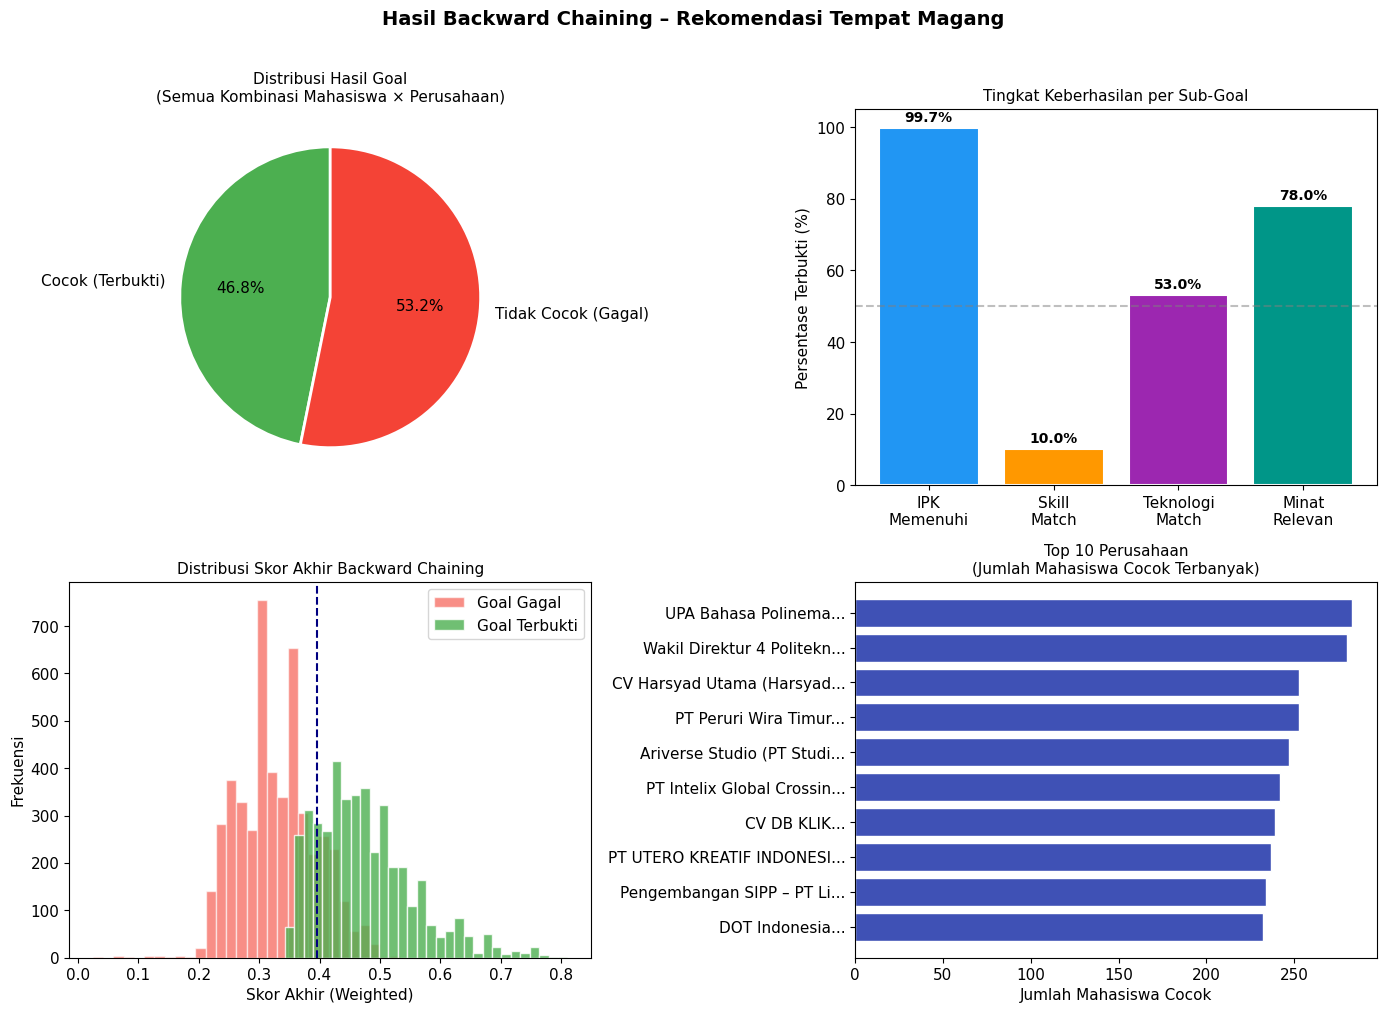

Visualisasi disimpan sebagai 'backward_chaining_result.png'


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hasil Backward Chaining – Rekomendasi Tempat Magang',
             fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1: Distribusi Goal (Pie Chart) ──
ax1 = axes[0, 0]
labels = ['Cocok (Terbukti)', 'Tidak Cocok (Gagal)']
sizes = [n_cocok, n_tidak]
colors = ['#4CAF50', '#F44336']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Distribusi Hasil Goal\n(Semua Kombinasi Mahasiswa × Perusahaan)', fontsize=11)

# ── Plot 2: Tingkat Keberhasilan Sub-Goal (Bar Chart) ──
ax2 = axes[0, 1]
sub_goals = ['IPK\nMemenuhi', 'Skill\nMatch', 'Teknologi\nMatch', 'Minat\nRelevan']
sg_cols = ['sg1_ipk', 'sg2_skill', 'sg3_teknologi', 'sg4_minat']
pct = [df_hasil[c].mean() * 100 for c in sg_cols]
colors_bar = ['#2196F3', '#FF9800', '#9C27B0', '#009688']
bars = ax2.bar(sub_goals, pct, color=colors_bar, edgecolor='white', linewidth=1.5)
ax2.set_ylim(0, 105)
ax2.set_ylabel('Persentase Terbukti (%)')
ax2.set_title('Tingkat Keberhasilan per Sub-Goal', fontsize=11)
for bar, val in zip(bars, pct):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

# ── Plot 3: Distribusi Skor Akhir (Histogram) ──
ax3 = axes[1, 0]
df_cocok_only = df_hasil[df_hasil['goal_terbukti'] == True]['skor_akhir']
df_gagal_only = df_hasil[df_hasil['goal_terbukti'] == False]['skor_akhir']
ax3.hist(df_gagal_only, bins=30, alpha=0.6, color='#F44336', label='Goal Gagal', edgecolor='white')
ax3.hist(df_cocok_only, bins=30, alpha=0.8, color='#4CAF50', label='Goal Terbukti', edgecolor='white')
ax3.set_xlabel('Skor Akhir (Weighted)')
ax3.set_ylabel('Frekuensi')
ax3.set_title('Distribusi Skor Akhir Backward Chaining', fontsize=11)
ax3.legend()
ax3.axvline(df_hasil['skor_akhir'].mean(), color='navy', linestyle='--',
            label=f"Mean={df_hasil['skor_akhir'].mean():.2f}")

# ── Plot 4: Top 10 Perusahaan berdasarkan jumlah mahasiswa cocok ──
ax4 = axes[1, 1]
top10_prs = per_perusahaan.sort_values(ascending=False).head(10)
nama_singkat = [kb.get_perusahaan(p)['Nama'][:25] + '...' for p in top10_prs.index]
ax4.barh(nama_singkat[::-1], top10_prs.values[::-1], color='#3F51B5', edgecolor='white')
ax4.set_xlabel('Jumlah Mahasiswa Cocok')
ax4.set_title('Top 10 Perusahaan\n(Jumlah Mahasiswa Cocok Terbanyak)', fontsize=11)

plt.tight_layout()
plt.savefig('backward_chaining_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi disimpan sebagai 'backward_chaining_result.png'")

## Cell 12 – Ekspor Hasil ke Excel

In [ ]:
# Ekspor hasil ke Excel
output_path = 'backward_chaining_hasil.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    # Sheet 1: Semua hasil
    cols_export = ['NIM', 'Nama_Mahasiswa', 'ID_Perusahaan', 'Nama_Perusahaan', 'Posisi',
                   'Durasi_Bulan', 'Status_Paid',
                   'sg1_ipk', 'sg2_skill', 'sg3_teknologi', 'sg4_minat',
                   'skor_ipk', 'skor_skill', 'skor_teknologi', 'skor_minat',
                   'skor_akhir', 'goal_terbukti']
    df_hasil[cols_export].to_excel(writer, sheet_name='Semua Hasil', index=False)

    # Sheet 2: Hanya yang cocok
    df_cocok_export = df_hasil[df_hasil['goal_terbukti'] == True].sort_values(
        by=['NIM', 'skor_akhir'], ascending=[True, False]
    )
    df_cocok_export[cols_export].to_excel(writer, sheet_name='Yang Cocok', index=False)

    # Sheet 3: Statistik per perusahaan
    stat_prs = df_hasil.groupby(['ID_Perusahaan', 'Nama_Perusahaan']).agg(
        total_mahasiswa=('NIM', 'count'),
        mahasiswa_cocok=('goal_terbukti', 'sum'),
        avg_skor=('skor_akhir', 'mean'),
        max_skor=('skor_akhir', 'max')
    ).reset_index()
    stat_prs['pct_cocok'] = (stat_prs['mahasiswa_cocok'] / stat_prs['total_mahasiswa'] * 100).round(1)
    stat_prs.to_excel(writer, sheet_name='Statistik Perusahaan', index=False)

print(f"Hasil diekspor ke '{output_path}'")
print(f"   Sheet 1 'Semua Hasil'          : {len(df_hasil):,} baris")
print(f"   Sheet 2 'Yang Cocok'           : {len(df_cocok_export):,} baris")
print(f"   Sheet 3 'Statistik Perusahaan' : {len(stat_prs)} baris")

Hasil diekspor ke 'backward_chaining_hasil.xlsx'
   Sheet 1 'Semua Hasil'          : 9,150 baris
   Sheet 2 'Yang Cocok'           : 4,284 baris
   Sheet 3 'Statistik Perusahaan' : 30 baris


## Cell 13 – Evaluasi: Perbandingan dengan Contoh Kasus Nyata

In [ ]:
# Ambil 3 mahasiswa berbeda untuk demo trace lengkap
sample_nims = [str(df_mahasiswa.iloc[i]['NIM']) for i in [0, 5, 10]]
sample_pids = ['P002', 'P007', 'P011']

print("DEMO TRACE BACKWARD CHAINING – 3 KASUS BERBEDA")
print("="*60)

for nim_x in sample_nims[:2]:
    for pid_x in sample_pids[:2]:
        hasil_x = engine.prove_goal(nim_x, pid_x, verbose=False)
        if 'error' not in hasil_x:
            status_str = 'COCOK' if hasil_x['goal_terbukti'] else 'TIDAK COCOK'
            print(f"\n{status_str}")
            print(f"  Mahasiswa : {hasil_x['Nama_Mahasiswa']} (NIM: {nim_x})")
            print(f"  Perusahaan: {hasil_x['Nama_Perusahaan'][:50]}")
            print(f"  Sub-goals : IPK={'Yes' if hasil_x['sg1_ipk'] else 'No'} | "
                  f"Skill={'Yes' if hasil_x['sg2_skill'] else 'No'} | "
                  f"Tek={'Yes' if hasil_x['sg3_teknologi'] else 'No'} | "
                  f"Minat={'Yes' if hasil_x['sg4_minat'] else 'No'}")
            print(f"  Skor akhir: {hasil_x['skor_akhir']:.4f}")

print("\n" + "="*60)
print("\nImplementasi Backward Chaining selesai!")
print(f"   Total kombinasi   : {len(df_hasil):,}")
print(f"   Goal terbukti     : {df_hasil['goal_terbukti'].sum():,} ({df_hasil['goal_terbukti'].mean()*100:.1f}%)")
print(f"   Rata-rata skor    : {df_hasil['skor_akhir'].mean():.4f}")

DEMO TRACE BACKWARD CHAINING – 3 KASUS BERBEDA

COCOK
  Mahasiswa : Dinda SIta (NIM: 848822)
  Perusahaan: Pengembangan SIPP – PT Link Apisindo Media & Dinas
  Sub-goals : IPK=Yes | Skill=No | Tek=Yes | Minat=Yes
  Skor akhir: 0.3631

COCOK
  Mahasiswa : Dinda SIta (NIM: 848822)
  Perusahaan: PT Time Door Indonesia
  Sub-goals : IPK=Yes | Skill=Yes | Tek=No | Minat=Yes
  Skor akhir: 0.4590

COCOK
  Mahasiswa : Dian Hastuti (NIM: 395767)
  Perusahaan: Pengembangan SIPP – PT Link Apisindo Media & Dinas
  Sub-goals : IPK=Yes | Skill=No | Tek=Yes | Minat=Yes
  Skor akhir: 0.3887

COCOK
  Mahasiswa : Dian Hastuti (NIM: 395767)
  Perusahaan: PT Time Door Indonesia
  Sub-goals : IPK=Yes | Skill=Yes | Tek=No | Minat=Yes
  Skor akhir: 0.4533


Implementasi Backward Chaining selesai!
   Total kombinasi   : 9,150
   Goal terbukti     : 4,284 (46.8%)
   Rata-rata skor    : 0.3965
